# LIBRARIES

In [6]:
import tarfile
import os
import pandas as pd
from pathlib import Path
import numpy as np
from collections import Counter
from typing import Sequence
import torch

from monai.transforms import ScaleIntensity, NormalizeIntensity


import nibabel as nib
from nibabel.funcs import as_closest_canonical
from matplotlib import pyplot as plt

DATA_DIR = Path(r"C:\Users\dibmir\dslab_med\data\pw\xdata\ATLAS3_Training_Raw")
#) KEY = "bLw,A>?jJ6j6KnV"

# FUNCTIONS

In [7]:
def t1_masks_path_extractor(
    data_dir: Path
    ) -> tuple[list[str], list[str]]:


    image_paths = []
    mask_paths = []

    for t1_file in data_dir.rglob("*T1w.nii.gz"):
        mask_file = next(
            t1_file.parent.glob("*lesion_mask.nii.gz"),
            None
        )

        if mask_file is not None:
            image_paths.append(str(t1_file))
            mask_paths.append(str(mask_file))

    if len(image_paths) > 0 and len(mask_paths) > 0:
        print("'image paths' and 'mask paths' lists properly created")

        if len(image_paths) != len(mask_paths):
            print("Warning: different number between images and masks")

    else:
        print("No file was found!")

    return image_paths, mask_paths

        

In [8]:
def reorder_imgs_to_canonical_space(
    *,
    image_paths: Sequence[str],
    mask_paths: Sequence[str],
) -> tuple[list[nib.nifti1.Nifti1Image], 
           list[nib.nifti1.Nifti1Image]]:
    
    images = []
    masks = []

    for img_path, msk_path in zip(image_paths, mask_paths):

        img = nib.load(img_path)
        msk = nib.load(msk_path)

        if nib.aff2axcodes(img.affine) != ("R", "A", "S"):
            img = nib.as_closest_canonical(img)

        if nib.aff2axcodes(msk.affine) != ("R", "A", "S"):
            msk = nib.as_closest_canonical(msk)

        images.append(img)
        masks.append(msk)

    return images, masks

In [9]:
def plot_orient_distr(image_paths: Sequence[str]):
    
    affine_lst = []
    for path in image_paths:
        affine_lst.append(nib.aff2axcodes(nib.load(path).affine))

    counts = Counter(affine_lst)
    counts = pd.Series(affine_lst).value_counts()

    counts.plot(kind='bar')

    plt.xlabel("Orientation")
    plt.ylabel("Number of brain volumes")
    plt.title("MRI orientation distribution")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()   

In [10]:
def zscore_nonzero(
    img: nib.Nifti1Image
    ) -> nib.Nifti1Image:
    
    img = img.astype(np.float32, copy=False)

    mask = img > 0
    m = img[mask].mean()
    s = img[mask].std()

    img[mask] -= m
    img[mask] /= (s + 1e-8)

    return img

In [11]:
# with tarfile.open(os.path.join(DATA_DIR, "ATLAS_R3.0_raw.tar.gz"), "r:gz") as tar:
#     tar.extractall(os.path.join(DATA_DIR, "xdata/"))

# DATA READING & PREP

## EDA

### Paths reading

In [12]:
image_paths, mask_paths = t1_masks_path_extractor(data_dir=DATA_DIR)


'image paths' and 'mask paths' lists properly created


In [13]:
nib.load(image_paths[0]).get_fdata()

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

### Images orientation distribution

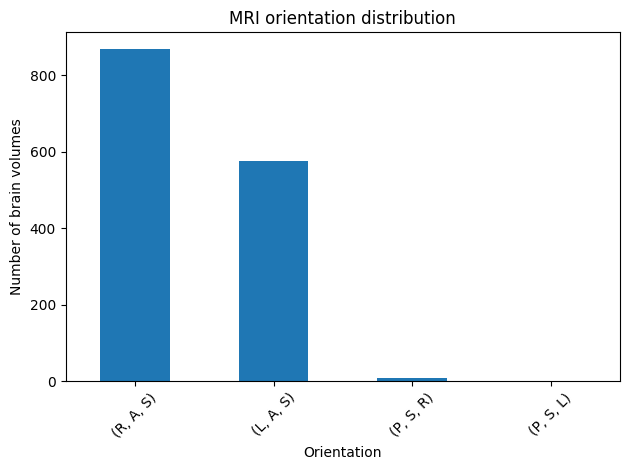

In [14]:
plot_orient_distr(image_paths=image_paths)

### Reorder to R.A.S.

In [15]:
images, masks = reorder_imgs_to_canonical_space(image_paths=image_paths,
                                                mask_paths=mask_paths)

pixdim[1,2,3] should be positive; setting to abs of pixdim values
pixdim[1,2,3] should be positive; setting to abs of pixdim values


In [20]:
type(nib.load(image_paths[0]).get_fdata())

numpy.ndarray

### Check for anisotropy

In [16]:
zooms = np.array([
    nib.load(p).header.get_zooms()[:3]
    for p in image_paths
])

df = pd.DataFrame(zooms, columns=["sx", "sy", "sz"])
print(df.describe())
print(df.quantile([0.01, 0.05, 0.5, 0.95, 0.99]))

                sx           sy           sz
count  1453.000000  1453.000000  1453.000000
mean      0.967674     0.989333     0.998816
std       0.206960     0.381273     0.550597
min       0.464015     0.250749     0.250749
25%       0.999901     1.000000     1.000000
50%       1.000000     1.000000     1.000000
75%       1.000000     1.000000     1.000000
max       5.999997     3.000000     6.199999
            sx        sy        sz
0.01  0.499992  0.436893  0.436893
0.05  0.500002  0.474894  0.474894
0.50  1.000000  1.000000  1.000000
0.95  1.100000  1.302083  1.026786
0.99  1.500000  3.000000  3.536071


In [17]:
tol = 0.5

is_isotropic = np.all(np.isclose(zooms, 1.0, atol=tol), axis=1)

count = np.sum(is_isotropic)
total = len(zooms)

print(f"{count} / {total} immagini ~ isotrope (1.0,1.0,1.0)")
print(f"Percentuale: {count/total:.2%}")

1264 / 1453 immagini ~ isotrope (1.0,1.0,1.0)
Percentuale: 86.99%


In [18]:
anisotropy = zooms.max(axis=1) / zooms.min(axis=1)
threshold = 1.5
outliers = np.where(anisotropy > threshold)[0]

print(f"Immagini fortemente anisotrope: {len(outliers)} / {len(zooms)}")
print("Esempi:")
print(zooms[outliers[:10]])

Immagini fortemente anisotrope: 136 / 1453
Esempi:
[[0.50000376 0.2507493  0.2507493 ]
 [0.4791666  0.4791667  5.9999976 ]
 [0.4999991  0.25074923 0.25074932]
 [0.8918047  0.89180475 6.        ]
 [0.89843744 0.8984375  6.0000014 ]
 [0.46874997 0.46874997 6.000004  ]
 [0.89843744 0.89843744 6.199999  ]
 [0.46875003 0.46875003 5.9999957 ]
 [0.7575758  0.7575758  6.000007  ]
 [0.50000197 0.25074926 0.25074923]]


* Since the major part of the images are in a voxel space around (1.0, 1.0, 1.0), with a range of deviation of 0.5, there are cases in which a strong anisotropy is registered.
* In particular, in 136 out of 1453 a max/min ratio of the voxel axes over 1.5 is revealed.

### Intensity normalization

In [5]:
normalizer = NormalizeIntensity()
type(normalizer)

monai.transforms.intensity.array.NormalizeIntensity

### TO DO

* provare scaling su singolo volume, e visualizzare
* provare il voxel spacing di monai su singolo volume e vedere come esce

In [24]:
import math
normalizer = NormalizeIntensity(nonzero=True)


def normalize_zscore(img: np.ndarray
                     ) -> torch.Tensor:

    img_ten = torch.from_numpy(img)
    img_ten = img_ten.unsqueeze(0)

    img_norm = normalizer(img_ten)

    return img_norm.squeeze(0)

batch_size = int(math.sqrt(len(images)))

images_norm = []

for i in range(0, len(images), batch_size):
    batch = images[i:i + batch_size]

    for img in batch:
        data = img.get_fdata(dtype=np.float32)
        images_norm.append(normalize_zscore(data))
        del data

MemoryError: Unable to allocate 2.63 GiB for an array with shape (348, 1008, 1008) and data type float64

In [75]:
imm = nib.load(image_paths[0])
imm.header.get_data_shape()
print(imm.header.get_zooms())

dx, dy, dz = imm.header.get_zooms()

ax_aspect = dx / dy
sag_aspect = dy / dz
cor_aspect = dz / dx

(np.float32(0.50000405), np.float32(0.47489437), np.float32(0.47489443))


In [76]:
imm.affine

array([[ 4.99916613e-01,  6.73210621e-03,  5.79243898e-03,
        -9.55918427e+01],
       [-6.70623779e-03,  4.73979771e-01, -2.87624598e-02,
        -1.27522034e+02],
       [-6.51633739e-03,  2.86797285e-02,  4.73987222e-01,
        -1.20466751e+02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]])

In [77]:
img = imm.get_fdata()
nib.aff2axcodes(imm.affine)

('R', 'A', 'S')

In [8]:
nib.affines.voxel_sizes(imm.affine)

array([0.99999633, 0.92361109, 0.92361109])

<OrthoSlicer3D: C:/Users/dibmir/dslab_med/data/pw/xdata/ATLAS3_Training_Raw/SOOP/sub-soop1701/ses-1/anat/sub-soop1701_ses-1_space-orig_desc-brain_T1w.nii.gz (480, 480, 24)>

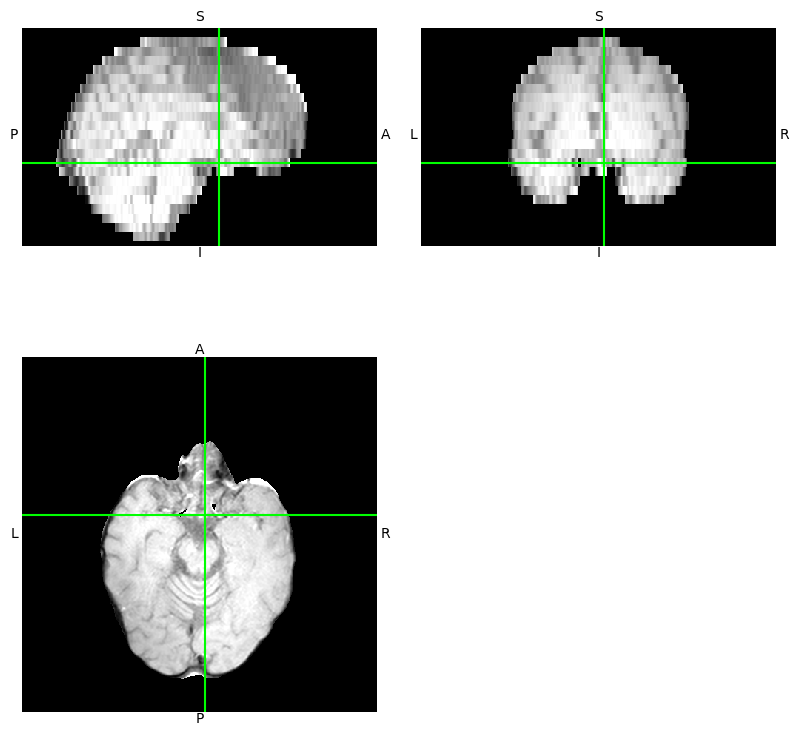

In [69]:
nib.load(image_paths[8]).orthoview()

In [86]:
img = nib.load(image_paths[79])
mask = nib.load(mask_paths[79])
img_can = as_closest_canonical(img)
img_can_data = img_can.get_fdata()
img_can.affine
print(mask.shape)

(320, 320, 30)


In [84]:
print(
    f"shape: {img_can.shape}\n",
    f"zooms: {img_can.header.get_zooms()}\n",
    f"affine: {nib.aff2axcodes(img_can.affine)}\n",
    f"Min: {img_can.get_fdata().min()}\n",
    f"Max: {img_can.get_fdata().max()}\n"
    )

shape: (30, 320, 320)
 zooms: (np.float32(6.000007), np.float32(0.7575758), np.float32(0.7575758))
 affine: ('R', 'A', 'S')
 Min: 0.0
 Max: 2126.501731351018



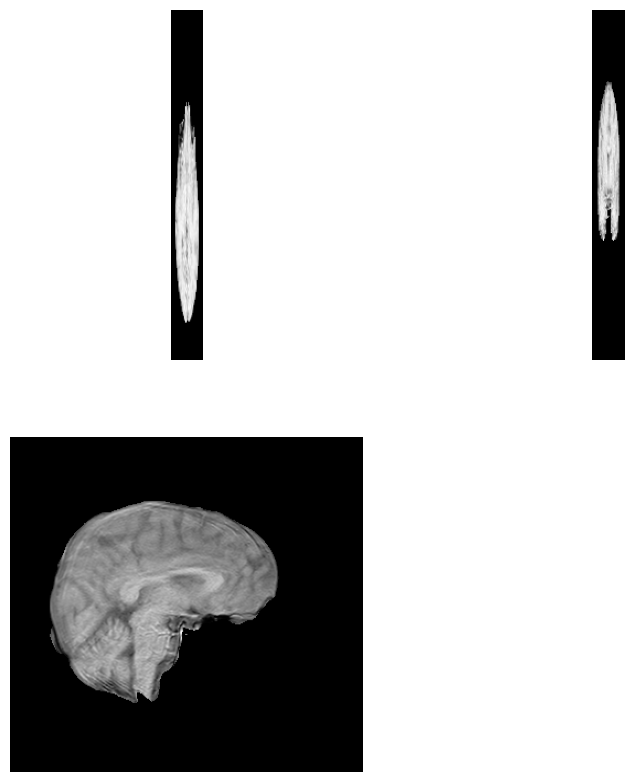

In [85]:
plt.figure(figsize=(10,10))
a1 = plt.subplot(2, 2, 1)
plt.imshow(img_can_data[:, :, img_can_data.shape[2]//2].T,cmap='Greys_r', origin='lower')#,vmin=-220,vmax=240)
a1.set_aspect(ax_aspect)
#plt.colorbar()
plt.axis('off')
a2 = plt.subplot(2, 2, 2)
plt.imshow(img_can_data[:, img_can_data.shape[1]//2, :].T, cmap='Greys_r', origin='lower')
a2.set_aspect(sag_aspect)
plt.axis('off')
a3 = plt.subplot(2, 2, 3)
plt.imshow(img_can_data[img_can_data.shape[0]//2, :, :].T, cmap='Greys_r', origin='lower')
a3.set_aspect(cor_aspect)

plt.axis('off')
plt.show()

In [ ]:
img_min_lst = []
img_max_lst = []
mask_min_lst = []
mask_max_lst = []

for i in range(len(images)):
    t1_img = nib.load(images[i])
    mask_img = nib.load(masks[i])
    
    img_min_lst.append(t1_img.get_fdata().min())
    img_max_lst.append(t1_img.get_fdata().max())
    mask_min_lst.append(mask_img.get_fdata().min())
    mask_max_lst.append(mask_img.get_fdata().max())


pixdim[1,2,3] should be positive; setting to abs of pixdim values
pixdim[1,2,3] should be positive; setting to abs of pixdim values


AttributeError: 'list' object has no attribute 'min'

In [10]:
print(f"valore minimo tra i minimi delle immagini: {min(img_min_lst)}")
print(f"valore massimo tra i massimi delle immagini: {max(img_max_lst)}")
print(f"valore minimo tra i minimi delle mask: {min(mask_min_lst)}")
print(f"valore massimo tra i massimi delle mask: {max(mask_max_lst)}")

valore minimo tra i minimi delle immagini: -5.0
valore massimo tra i massimi delle immagini: 5626440.646018982
valore minimo tra i minimi delle mask: 0.0
valore massimo tra i massimi delle mask: 1.0000000591389835


<built-in method max of numpy.ndarray object at 0x0000015A845D7390>


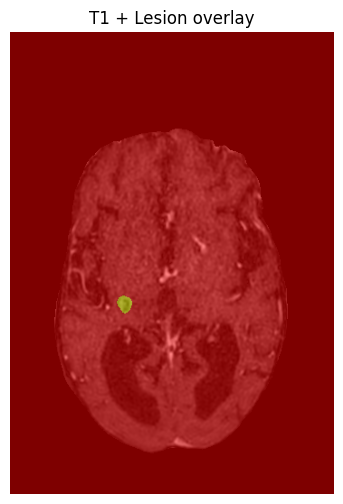

In [ ]:
def show_overlay(t1_path, mask_path, slice_idx=None):

    t1 = nib.load(t1_path).get_fdata()
    mask = nib.load(mask_path).get_fdata()

    if slice_idx is None:
        slice_idx = t1.shape[2] // 2

    plt.figure(figsize=(6,6))

    plt.imshow(t1[:, :, slice_idx].T, cmap="gray", origin="lower")
    plt.imshow(mask[:, :, slice_idx].T, cmap="autumn", alpha=0.5, origin="lower")

    plt.title("T1 + Lesion overlay")
    plt.axis("off")
    plt.show()

show_overlay(images[100], masks[100])

NameError: name 'image_paths' is not defined